Import All the Liabraries

In [3]:

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
# Machine Learning - Core
import sklearn

# Machine Learning - Specific functions
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, f1_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.impute import SimpleImputer

# Others
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 8)



In [5]:
# Print versions to confirm

print(f" Pandas: {pd.__version__}")
print(f" NumPy: {np.__version__}")
print(f" Matplotlib: {plt.matplotlib.__version__}")
print(f" Seaborn: {sns.__version__}")
print(f" Scikit-learn: {sklearn.__version__}")
print("="*60)
print(" All libraries imported successfully!")

 Pandas: 3.0.5
 NumPy: 2.5.2
 Matplotlib: 3.11.1
 Seaborn: 0.13.2
 Scikit-learn: 1.9.0
 All libraries imported successfully!


Load Dataset

In [12]:
# File path check
import os
if os.path.exists('../diabetes.csv'):
    df = pd.read_csv('../diabetes.csv')
    print(" Loaded from: ../diabetes.csv")
elif os.path.exists('diabetes.csv'):
    df = pd.read_csv('diabetes.csv')
    print(" Loaded from: diabetes.csv")
else:
    print(" File not found! Please check.")


print("DATASET OVERVIEW")

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst 5 rows:")
display(df.head())

 Loaded from: diabetes.csv
DATASET OVERVIEW
Shape: (768, 9)
Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


DATA EXPLORATION

In [13]:

# 1. Basic Info
print("\n Data Types:")
print(df.dtypes)

# 2. Statistical Summary
print("\n Statistical Summary:")
display(df.describe())

# 3. Missing Values
print("\n Missing Values:")
print(df.isnull().sum())

# 4. Zero Values (Missing Indicators)
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("\n Zero Values (likely missing):")
for col in zero_cols:
    zero_count = (df[col] == 0).sum()
    print(f"   {col}: {zero_count} ({zero_count/len(df)*100:.1f}%)")

# 5. Class Distribution
print("\n Class Distribution:")
print(df['Outcome'].value_counts())
print(f"Class Ratio: {df['Outcome'].value_counts()[0]/df['Outcome'].value_counts()[1]:.2f}")



 Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

 Statistical Summary:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000



 Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

 Zero Values (likely missing):
   Glucose: 5 (0.7%)
   BloodPressure: 35 (4.6%)
   SkinThickness: 227 (29.6%)
   Insulin: 374 (48.7%)
   BMI: 11 (1.4%)

 Class Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64
Class Ratio: 1.87


Visualizations


 Generating Visualizations...


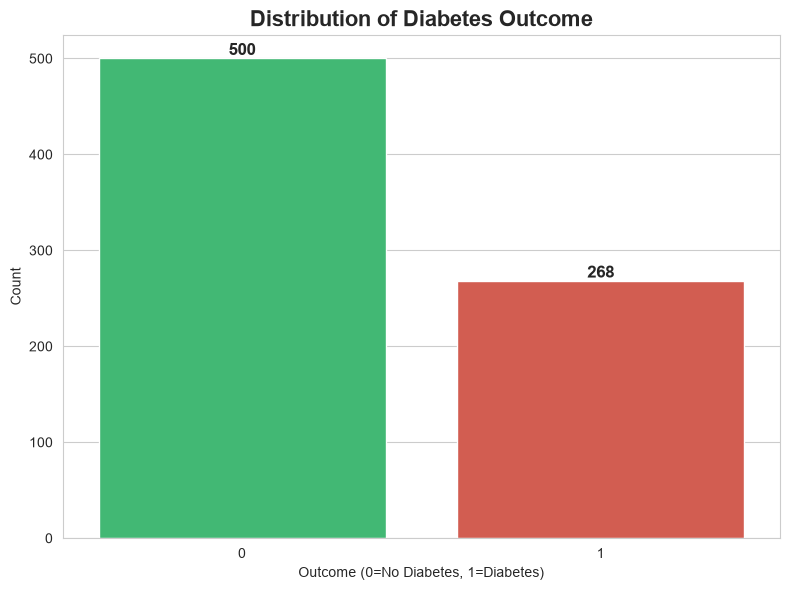

 Saved: visuals/target_distribution.png


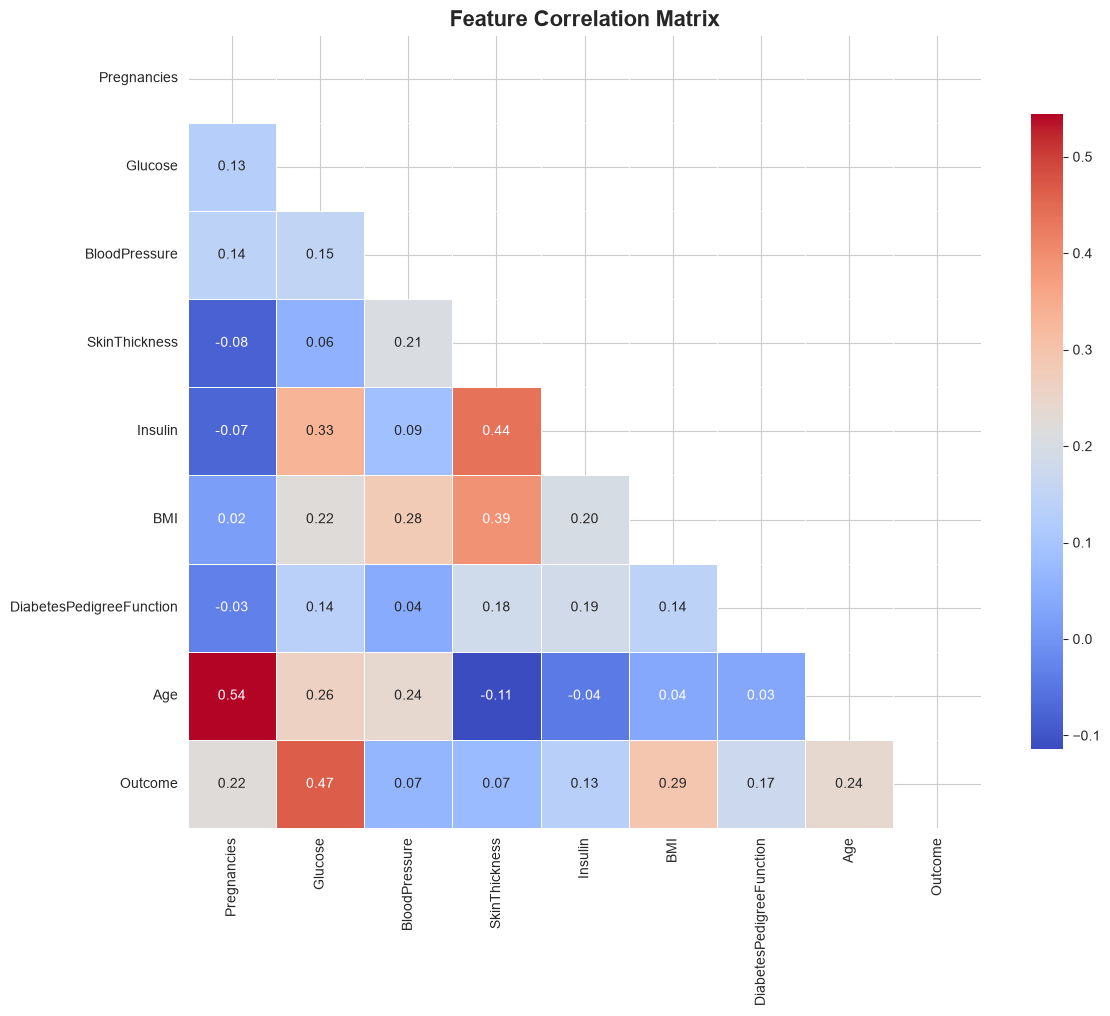

 Saved: visuals/correlation_heatmap.png


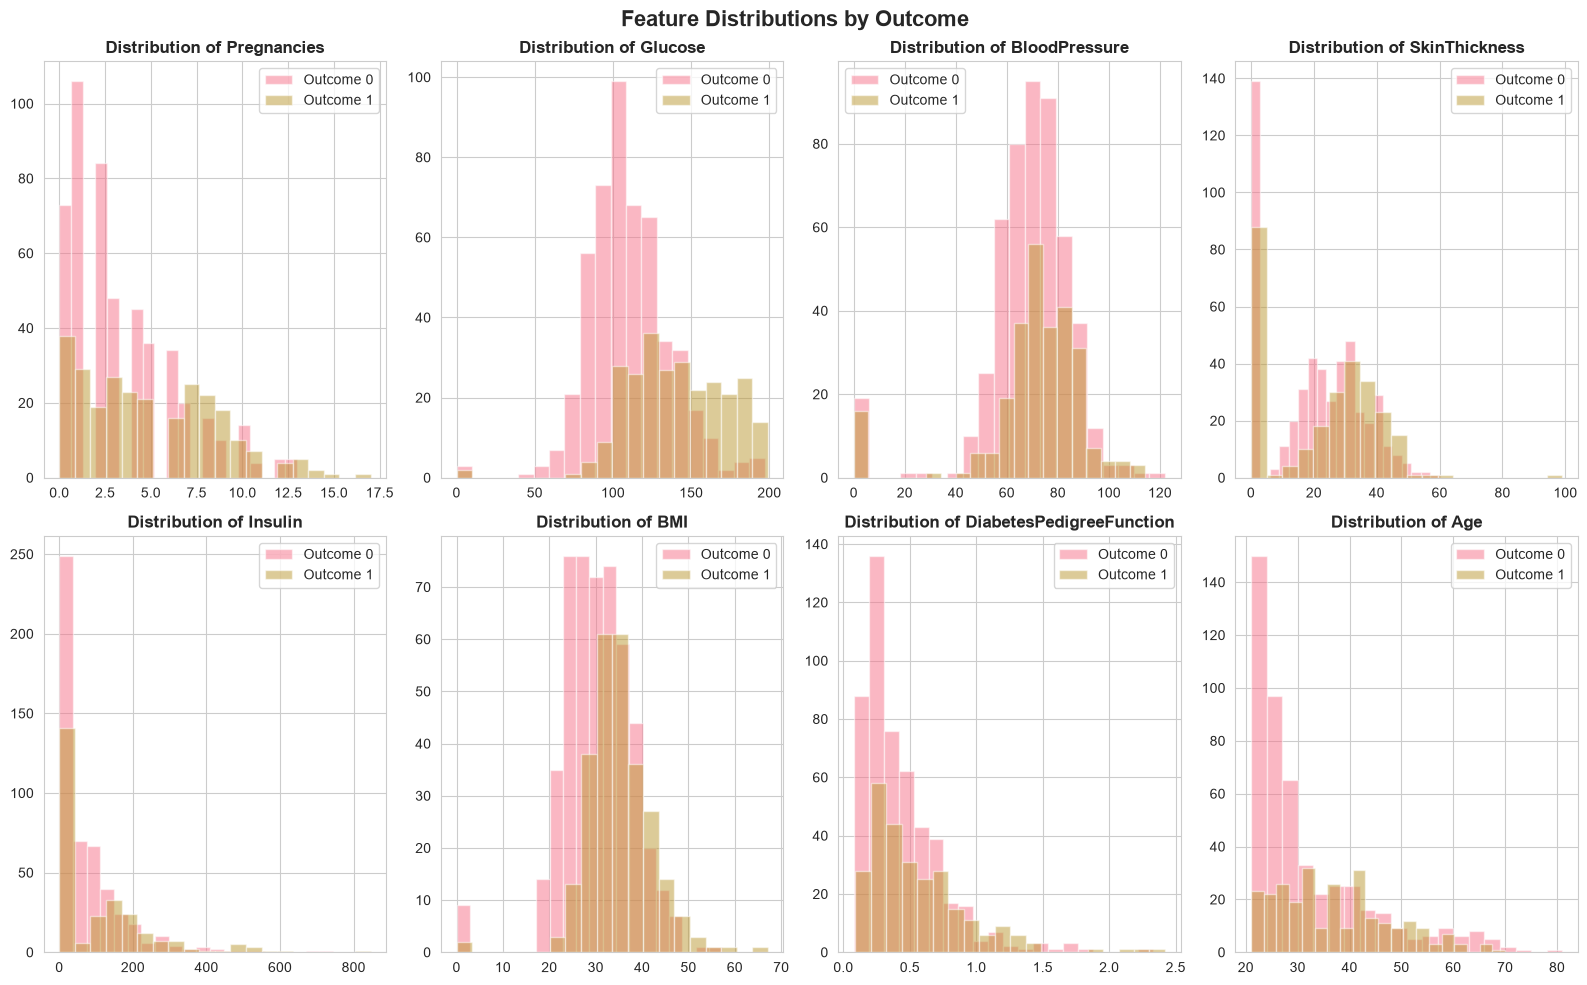

 Saved: visuals/feature_distributions.png


In [14]:
os.makedirs('visuals', exist_ok=True)
print("\n Generating Visualizations...")

# 1. Target Distribution
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Outcome', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title('Distribution of Diabetes Outcome', fontsize=16, fontweight='bold')
plt.xlabel('Outcome (0=No Diabetes, 1=Diabetes)')
plt.ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('visuals/target_distribution.png', dpi=300)
plt.show()
print(" Saved: visuals/target_distribution.png")

# 2. Correlation Heatmap
plt.figure(figsize=(12, 10))
correlation = df.corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))
sns.heatmap(correlation, mask=mask, annot=True, cmap='coolwarm', 
            fmt='.2f', linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('visuals/correlation_heatmap.png', dpi=300)
plt.show()
print(" Saved: visuals/correlation_heatmap.png")

# 3. Feature Distributions
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.ravel()
for idx, col in enumerate(df.columns[:-1]):
    for outcome in [0, 1]:
        df[df['Outcome'] == outcome][col].hist(alpha=0.5, label=f'Outcome {outcome}', 
                                                bins=20, ax=axes[idx])
    axes[idx].set_title(f'Distribution of {col}', fontweight='bold')
    axes[idx].legend()
plt.suptitle('Feature Distributions by Outcome', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('visuals/feature_distributions.png', dpi=300)
plt.show()
print(" Saved: visuals/feature_distributions.png")


DATA PREPROCESSING

In [20]:


# 1. Replace 0 with NaN
df_clean = df.copy()
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df_clean[zero_cols] = df_clean[zero_cols].replace(0, np.nan)

# 2. Impute with SimpleImputer
imputer = SimpleImputer(strategy='median')
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

X_imputed = imputer.fit_transform(X)
print(" Missing values imputed with median!")

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.3, random_state=42, stratify=y
)

# 4. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(" Preprocessing complete!")

 Missing values imputed with median!
Training set: 537 samples
Test set: 231 samples
 Preprocessing complete!


Model Training

In [21]:
# 1. Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)
print(" Random Forest trained!")

# 2. Logistic Regression
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr_model.fit(X_train_scaled, y_train)
print(" Logistic Regression trained!")

# 3. Cross-Validation (Random Forest)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model, X_train_scaled, y_train, cv=cv, scoring='f1')
print(f"\n Cross-Validation F1-Scores: {cv_scores}")
print(f"Mean F1-Score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

 Random Forest trained!
 Logistic Regression trained!

 Cross-Validation F1-Scores: [0.55       0.675      0.65060241 0.71428571 0.73809524]
Mean F1-Score: 0.6656 (+/- 0.0653)


Model Evaluation

In [22]:

y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]
y_pred_lr = lr_model.predict(X_test_scaled)


print(" MODEL EVALUATION")


# 1. Classification Report
print("\n Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['No Diabetes', 'Diabetes']))

# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
tn, fp, fn, tp = cm.ravel()

# 3. Performance Metrics
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
specificity = tn / (tn + fp)
f1 = 2 * (precision * recall) / (precision + recall)
roc_auc = roc_auc_score(y_test, y_pred_proba_rf)

print("\n Performance Metrics:")
print(f" Accuracy: {accuracy:.4f}")
print(f" Precision: {precision:.4f}")
print(f" Recall (Sensitivity): {recall:.4f}")
print(f" Specificity: {specificity:.4f}")
print(f" F1-Score: {f1:.4f}")
print(f" ROC-AUC: {roc_auc:.4f}")

 MODEL EVALUATION

 Random Forest Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.83      0.76      0.79       150
    Diabetes       0.62      0.72      0.66        81

    accuracy                           0.74       231
   macro avg       0.72      0.74      0.73       231
weighted avg       0.76      0.74      0.75       231


 Performance Metrics:
 Accuracy: 0.7446
 Precision: 0.6170
 Recall (Sensitivity): 0.7160
 Specificity: 0.7600
 F1-Score: 0.6629
 ROC-AUC: 0.8376


Results Visualization

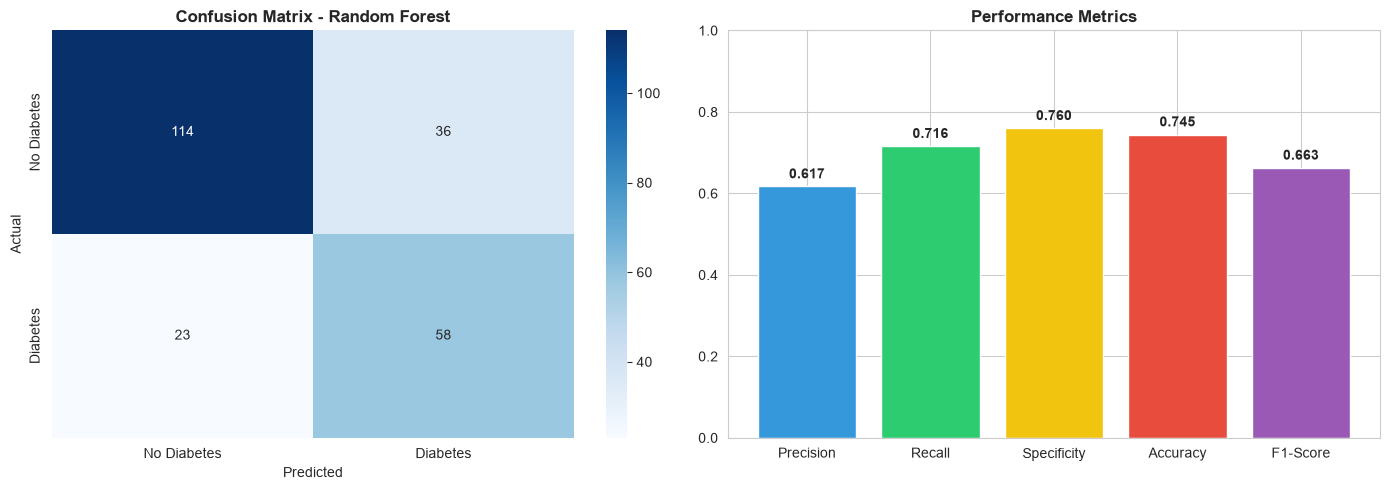

 Saved: visuals/model_metrics.png


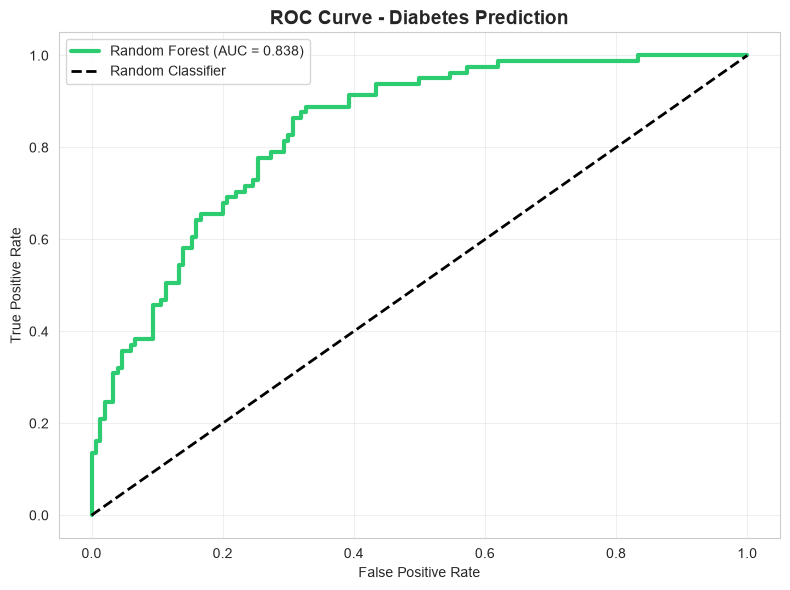

 Saved: visuals/roc_curve.png


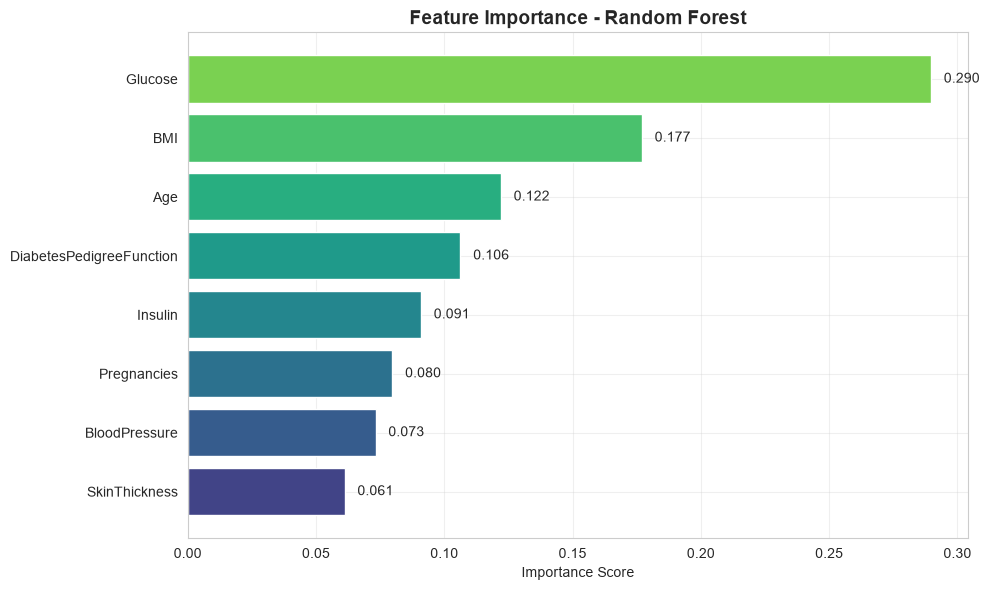

 Saved: visuals/feature_importance.png

 Top 5 Most Important Features:
                    Feature  Importance
4                   Insulin    0.090900
6  DiabetesPedigreeFunction    0.106286
7                       Age    0.122055
5                       BMI    0.177001
1                   Glucose    0.289683


In [23]:
# 1. Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
axes[0].set_title('Confusion Matrix - Random Forest', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

metrics_dict = {
    'Precision': precision,
    'Recall': recall,
    'Specificity': specificity,
    'Accuracy': accuracy,
    'F1-Score': f1
}
axes[1].bar(metrics_dict.keys(), metrics_dict.values(), 
            color=['#3498db', '#2ecc71', '#f1c40f', '#e74c3c', '#9b59b6'])
axes[1].set_title('Performance Metrics', fontweight='bold')
axes[1].set_ylim(0, 1)
for i, (k, v) in enumerate(metrics_dict.items()):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('visuals/model_metrics.png', dpi=300)
plt.show()
print(" Saved: visuals/model_metrics.png")

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_rf)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc:.3f})', linewidth=3, color='#2ecc71')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Diabetes Prediction', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('visuals/roc_curve.png', dpi=300)
plt.show()
print(" Saved: visuals/roc_curve.png")

# 3. Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(feature_importance)))
bars = plt.barh(feature_importance['Feature'], feature_importance['Importance'], color=colors)
plt.xlabel('Importance Score')
plt.title('Feature Importance - Random Forest', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.005, bar.get_y() + bar.get_height()/2, 
             f'{width:.3f}', ha='left', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('visuals/feature_importance.png', dpi=300)
plt.show()
print(" Saved: visuals/feature_importance.png")

print("\n Top 5 Most Important Features:")
print(feature_importance.tail(5))

Save Predictions

In [24]:
predictions_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_rf,
    'Probability': y_pred_proba_rf
})
predictions_df.to_csv('visuals/predictions.csv', index=False)
print(" Saved: visuals/predictions.csv")

 Saved: visuals/predictions.csv


Final Summary

In [25]:
print(f"""
 DATASET: Pima Indians Diabetes Database
 TOTAL SAMPLES: {len(df)}
 PROBLEM TYPE: Binary Classification

 BEST MODEL: Random Forest Classifier
 PERFORMANCE:
   - Accuracy: {accuracy*100:.2f}%
   - Precision: {precision*100:.2f}%
   - Recall: {recall*100:.2f}%
   - F1-Score: {f1*100:.2f}%
   - ROC-AUC: {roc_auc:.4f}

 TOP 3 FEATURES:
   1. {feature_importance.iloc[-1]['Feature']}
   2. {feature_importance.iloc[-2]['Feature']}
   3. {feature_importance.iloc[-3]['Feature']}

 All outputs saved in 'visuals' folder!
""")

print(" Project completed successfully! ")


 DATASET: Pima Indians Diabetes Database
 TOTAL SAMPLES: 768
 PROBLEM TYPE: Binary Classification

 BEST MODEL: Random Forest Classifier
 PERFORMANCE:
   - Accuracy: 74.46%
   - Precision: 61.70%
   - Recall: 71.60%
   - F1-Score: 66.29%
   - ROC-AUC: 0.8376

 TOP 3 FEATURES:
   1. Glucose
   2. BMI
   3. Age

 All outputs saved in 'visuals' folder!

 Project completed successfully! 
